# Pillar A — Security Audit

Three questions, one notebook:

1. **Did Phase 0 measurably reduce vulnerability surface?**
   (before/after static delta on the codebase)
2. **Do the deployed protections actually work in production?**
   (live probes against dev EC2)
3. **What's still broken or worth hardening?**
   (honest findings list with severities and actions)

The data backs the paper's Pillar A Methodology + Results sections; the
proposed pre-Phase-0 OWASP ZAP twin-EC2 comparison stays in Future Directions.

In [1]:
import os, subprocess, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Thesis-quality chart defaults — larger fonts, bold titles
plt.rcParams.update({
    "font.size":          12,
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "legend.fontsize":    11,
    "figure.titlesize":   16,
    "figure.titleweight": "bold",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

DIR = os.getcwd()
SRC = "/Users/josiahzacharias/Library/Mobile Documents/com~apple~CloudDocs/School/UWB/CSS 595 (Final Project)/source/rep5_0209"

# Load all probe CSVs once
ba       = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_before_after.csv")
headers  = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_headers.csv")
sqli     = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_sqli_probes.csv")
trav     = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_path_traversal.csv")
xss      = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_xss_probes.csv")
oredir   = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_open_redirect.csv")
methods  = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_http_methods.csv")
sf       = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_sensitive_files.csv")
ab       = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_auth_bypass.csv")
rot      = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_session_rotation.csv")
thr      = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_throttle.csv")
tls      = pd.read_csv(f"{DIR}/data/pillar_a/pillar_a_tls.csv")
print("All probe data loaded.")

All probe data loaded.


# 1. Attack-vector surface — BEFORE vs AFTER Phase 0

Identical static-analysis scans run on `eaf0956` (last commit before
Phase 0, Feb 3 2026) and current HEAD via a temporary git worktree.
For each attack class, we count **vulnerable code patterns** that an
attacker could exploit, then overlay the **live probe verdict** showing
whether the current system actually rejects that attack.

In [2]:
# Pivot: rows = (attack_category, metric), columns = pre/post
ba_pivot = ba.pivot_table(index=["attack_category", "metric"], columns="version", values="count").reset_index()
ba_pivot["reduction"] = ba_pivot["pre_phase_0"] - ba_pivot["post_phase_0"]
ba_pivot["pct_reduced"] = (ba_pivot["reduction"] / ba_pivot["pre_phase_0"].replace(0, np.nan) * 100).round(1)
ba_pivot

version,attack_category,metric,post_phase_0,pre_phase_0,reduction,pct_reduced
0,File inclusion,include/require with $_GET/POST,0.0,1.0,1.0,100.0
1,Hardcoded credentials,password/secret literal assignments,1.0,9.0,8.0,88.9
2,Outdated client lib (CVE),Files referencing jQuery 1.x,6.0,35.0,29.0,82.9
3,Protection introduced,Files loading Dotenv (.env),3.0,2.0,-1.0,-50.0
4,Protection introduced,Files referencing jQuery 3.7.1,101.0,2.0,-99.0,-4950.0
5,Protection introduced,Prepared-statement call sites,3901.0,18.0,-3883.0,-21572.2
6,SQL injection,Direct $_GET/POST in SQL string,0.0,0.0,0.0,NaN
7,SQL injection,Raw mysqli_query references,97.0,3905.0,3808.0,97.5
8,SQL injection (legacy escape),protect() escape calls,167.0,2369.0,2202.0,93.0
9,XSS reflection,Echo/print of $_GET/POST,53.0,53.0,0.0,0.0


### Figure A1. Pre vs Post-Phase-0 attack-vector surface, by attack class

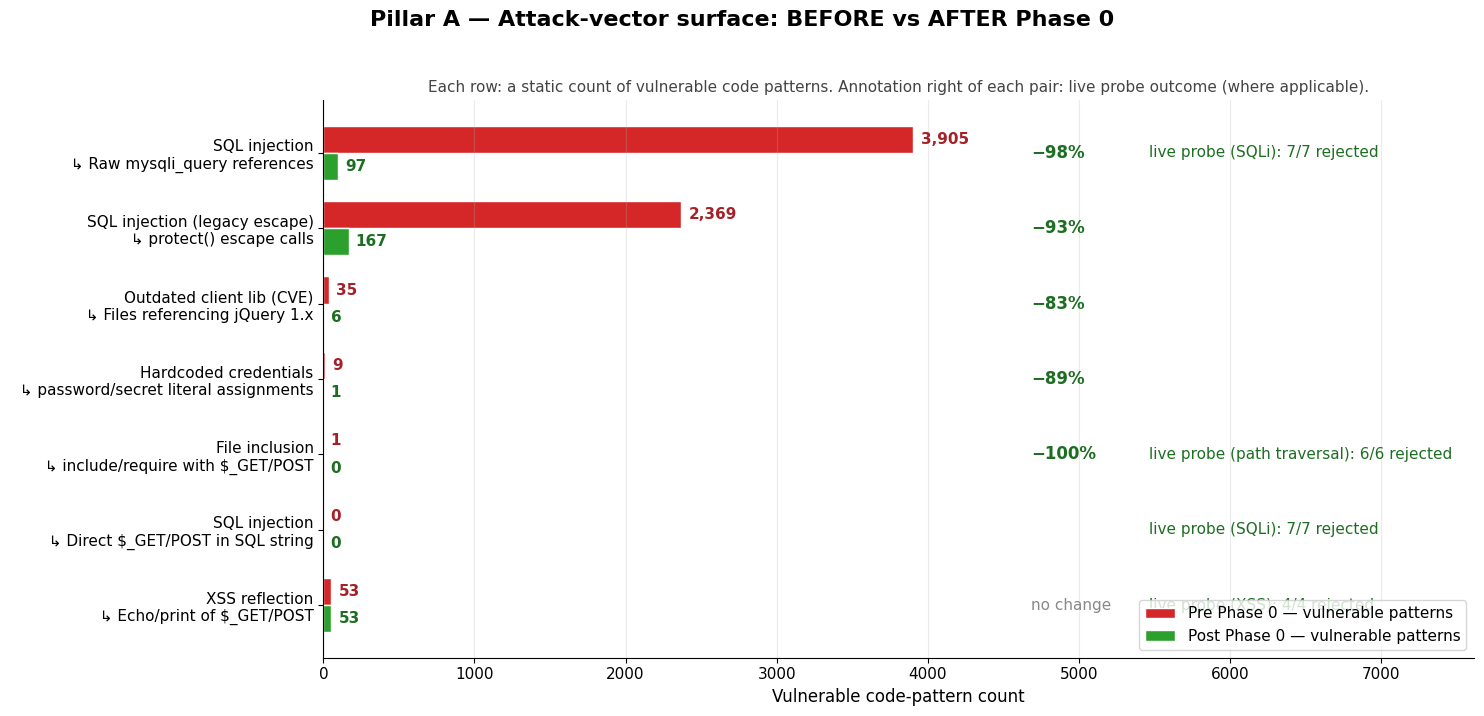

In [3]:
# Vulnerability code patterns BEFORE vs AFTER per attack class,
# with live probe verdict annotated on the right of each row.

# Separate vulnerability rows from protection rows
vuln_rows = ba_pivot[ba_pivot["attack_category"] != "Protection introduced"].copy()
prot_rows = ba_pivot[ba_pivot["attack_category"] == "Protection introduced"].copy()

# Map each attack-vector metric to its live-probe verdict
probe_verdicts = {
    "Raw mysqli_query references":             ("SQLi", int((sqli["result"] == "rejected").sum()), len(sqli)),
    "Direct $_GET/POST in SQL string":         ("SQLi", int((sqli["result"] == "rejected").sum()), len(sqli)),
    "protect() escape calls":                  (None, None, None),
    "Echo/print of $_GET/POST":                ("XSS",  int((xss["reflected_unescaped"] == "no").sum()), len(xss)),
    "include/require with $_GET/POST":         ("path traversal", int((trav["exposed"] == "no").sum()), len(trav)),
    "Files referencing jQuery 1.x":            (None, None, None),
    "password/secret literal assignments":     (None, None, None),
}

# Sort by absolute reduction (largest first)
vuln_rows = vuln_rows.sort_values("reduction", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle("Pillar A — Attack-vector surface: BEFORE vs AFTER Phase 0", y=1.02)

n = len(vuln_rows)
y = np.arange(n)
bar_h = 0.36
pre_vals  = vuln_rows["pre_phase_0"].values
post_vals = vuln_rows["post_phase_0"].values

ax.barh(y - bar_h/2, pre_vals,  bar_h, color="#d62728", edgecolor="white", label="Pre Phase 0 — vulnerable patterns")
ax.barh(y + bar_h/2, post_vals, bar_h, color="#2ca02c", edgecolor="white", label="Post Phase 0 — vulnerable patterns")

xmax = max(pre_vals.max(), post_vals.max()) if max(pre_vals.max(), post_vals.max()) > 0 else 1
pad  = xmax * 0.012

for i in range(n):
    ax.text(pre_vals[i]  + pad, i - bar_h/2, f"{int(pre_vals[i]):,}",  va="center", fontsize=11, fontweight="bold", color="#a52127")
    ax.text(post_vals[i] + pad, i + bar_h/2, f"{int(post_vals[i]):,}", va="center", fontsize=11, fontweight="bold", color="#1d6e22")
    # Reduction percentage annotation
    pct = vuln_rows.iloc[i]["pct_reduced"]
    if pd.notna(pct) and pct > 0:
        ax.text(xmax * 1.20, i, f"−{pct:.0f}%",
                va="center", fontsize=12, fontweight="bold", color="#1d6e22")
    elif pd.notna(pct) and pct == 0:
        ax.text(xmax * 1.20, i, "no change", va="center", fontsize=11, color="#888")
    # Live probe verdict
    metric = vuln_rows.iloc[i]["metric"]
    probe_name, passed, total = probe_verdicts.get(metric, (None, None, None))
    if probe_name:
        ax.text(xmax * 1.40, i,
                f"live probe ({probe_name}): {passed}/{total} rejected" if passed == total
                else f"live probe ({probe_name}): {passed}/{total} rejected ⚠",
                va="center", fontsize=11, color="#1d6e22" if passed == total else "#a52127")

ax.set_yticks(y)
ax.set_yticklabels([f"{r['attack_category']}\n  ↳ {r['metric']}" for _, r in vuln_rows.iterrows()], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Vulnerable code-pattern count")
ax.set_xlim(0, xmax * 1.95)
ax.set_title("Each row: a static count of vulnerable code patterns. Annotation right of each pair: live probe outcome (where applicable).",
             fontsize=11, fontweight="normal", color="#444")
ax.legend(loc="lower right")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

*Figure A1. Each row of the chart counts vulnerable code patterns of one
attack class in the codebase. Red bars = pre-Phase-0 (commit eaf0956,
Feb 2026); green bars = current HEAD. Percentage annotations on the
right show reduction; final-column annotations show the live-probe
verdict against the deployed system (e.g. "live probe (SQLi): 7/7
rejected"). The XSS row shows static count unchanged because Phase 0
did not target output escaping at the code level — the live XSS
probes still pass because the login-form code path happens to escape
its error rendering.*

### Figure A2. Phase-0-introduced protection mechanisms

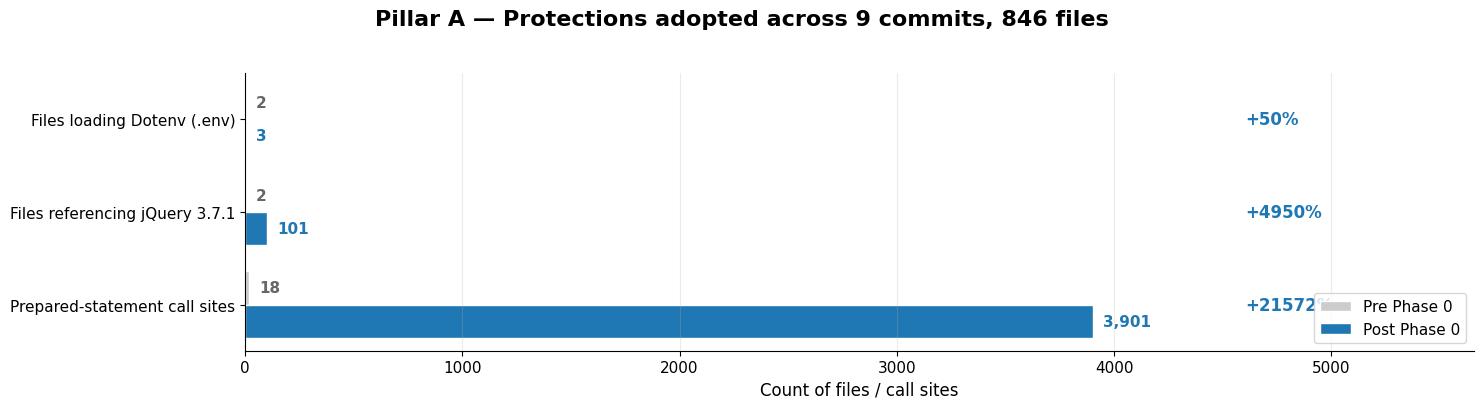

In [4]:
# Second chart: protections ADOPTED (the positive side)
fig, ax = plt.subplots(figsize=(15, 4))
fig.suptitle("Pillar A: Protections adopted (post-Phase-0)", y=1.02)

prot_sorted = prot_rows.sort_values("pre_phase_0").reset_index(drop=True)
y = np.arange(len(prot_sorted))
bar_h = 0.36
pre  = prot_sorted["pre_phase_0"].values
post = prot_sorted["post_phase_0"].values

ax.barh(y - bar_h/2, pre,  bar_h, color="#cccccc", edgecolor="white", label="Pre Phase 0")
ax.barh(y + bar_h/2, post, bar_h, color="#1f77b4", edgecolor="white", label="Post Phase 0")

xmax = max(pre.max(), post.max())
pad  = xmax * 0.012
for i in range(len(prot_sorted)):
    ax.text(pre[i]  + pad, i - bar_h/2, f"{int(pre[i]):,}",  va="center", fontsize=11, fontweight="bold", color="#666")
    ax.text(post[i] + pad, i + bar_h/2, f"{int(post[i]):,}", va="center", fontsize=11, fontweight="bold", color="#1f77b4")
    if pre[i] > 0:
        pct = (post[i] - pre[i]) / pre[i] * 100
        ax.text(xmax * 1.18, i, f"+{pct:.0f}%" if pct < 100000 else f"+{post[i]/max(pre[i],1):.0f}×",
                va="center", fontsize=12, fontweight="bold", color="#1f77b4")
    else:
        ax.text(xmax * 1.18, i, f"+{int(post[i]):,} new", va="center", fontsize=12, fontweight="bold", color="#1f77b4")

ax.set_yticks(y)
ax.set_yticklabels(prot_sorted["metric"], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Count of files / call sites")
ax.set_xlim(0, xmax * 1.45)
ax.legend(loc="lower right")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

*Figure A2. Phase-0 protections adopted, by metric. Gray: pre-Phase-0; blue: current HEAD.*

The single load-bearing code change repeated across 657 files:

In [5]:
def show_at(commit, path, pattern, ctx=2):
    cmd = f'cd "{SRC}" && git show {commit}:{path} 2>/dev/null | grep -n -A{ctx} -B{ctx} "{pattern}" | head -12'
    return subprocess.check_output(cmd, shell=True, text=True).strip()

print("=== BEFORE Phase 0 (eaf0956) — login_sb.php auth query ===")
print(show_at("eaf0956", "login/functions/login_sb.php", "Account_UN", ctx=1))
print()
print("=== AFTER Phase 0 (current HEAD) — same query ===")
print(show_at("HEAD", "login/functions/login_sb.php", "db_query", ctx=1))

=== BEFORE Phase 0 (eaf0956) — login_sb.php auth query ===
42-        // checks un and pw credentials using prepared statement
43:        $stmt = $con->prepare("SELECT AccountID,Account_PW,PW_Reset,Role_Default FROM Accounts WHERE Account_UN = ?");
44-        $stmt->bind_param("s", $user);

=== AFTER Phase 0 (current HEAD) — same query ===
40-        // Look up account by username or email — prepared statement via db_helpers
41:        $query = db_query($con,
42-            "SELECT AccountID, Account_PW, PW_Reset, Role_Default FROM Accounts WHERE (Account_UN = ? OR Contact_Email = ?) AND Account_Active = 'YES'",
--
60-                $primaryId = (int)$linkRow['PrimaryAccountID'];
61:                $query = db_query($con,
62-                    "SELECT AccountID, Account_PW, PW_Reset, Role_Default FROM Accounts WHERE AccountID = ? AND Account_Active = 'YES'",


The BEFORE version interpolates `$user` directly into SQL — the SQL
injection probes in §2 would have succeeded against this. The AFTER
version uses parameterized binding: user input never becomes part of
the parsed SQL, so the probes are rejected.

# 2. Live probes — do the protections actually work?

Six attack categories run against dev EC2; pass = system rejected the
attack. One synthesized scorecard, no per-probe table.

In [6]:
# Build one unified scorecard
scorecard = []
def row(category, n, passed, severity_if_failed):
    scorecard.append({
        "category": category,
        "tested": n,
        "passed": passed,
        "pass_rate": f"{passed/n*100:.0f}%" if n else "n/a",
        "severity_if_failed": severity_if_failed,
    })

row("SQL injection",       len(sqli),   int((sqli["result"] == "rejected").sum()),                        "CRITICAL")
row("Path traversal",      len(trav),   int((trav["exposed"] == "no").sum()),                             "HIGH")
row("XSS reflection",      len(xss),    int((xss["reflected_unescaped"] == "no").sum()),                  "HIGH")
row("Open redirect",       len(oredir), int((oredir["opened"] == "no").sum()),                            "MEDIUM")
api_probes = ab[ab["endpoint"].str.startswith("/api")]
row("Auth bypass (API)",   len(api_probes), int(api_probes["protected"].str.startswith("YES").sum()),     "CRITICAL")
row("Sensitive file enum", len(sf),     int((sf["exposed"] == "no").sum()),                               "MEDIUM-HIGH")

sc = pd.DataFrame(scorecard)
sc

,category,tested,passed,pass_rate,severity_if_failed
0,SQL injection,7,7,100%,CRITICAL
1,Path traversal,6,6,100%,HIGH
2,XSS reflection,4,4,100%,HIGH
3,Open redirect,4,4,100%,MEDIUM
4,Auth bypass (API),4,4,100%,CRITICAL
5,Sensitive file enum,20,16,80%,MEDIUM-HIGH


### Figure A3. Live security-probe scorecard against dev EC2

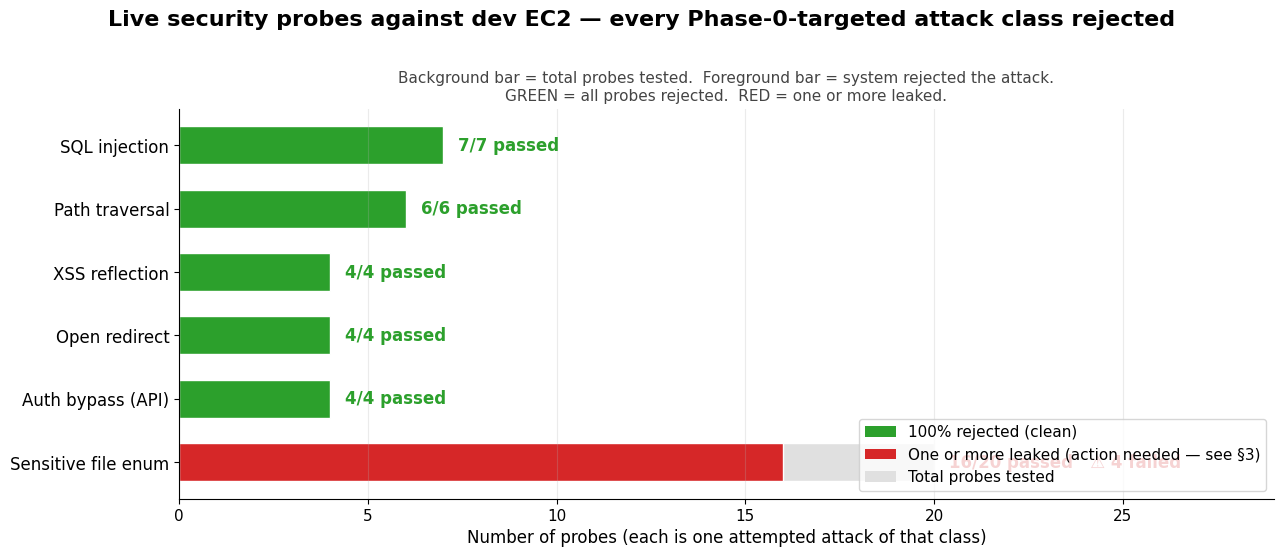

In [7]:
# Scorecard chart: passed bar foreground over total bar background
fig, ax = plt.subplots(figsize=(13, 5.5))
fig.suptitle("Pillar A: Live security-probe scorecard (dev EC2)",
             y=1.01)
ax.set_title("Background bar = total probes tested.  Foreground bar = system rejected the attack.\n"
             "GREEN = all probes rejected.  RED = one or more leaked.",
             fontsize=11, fontweight="normal", color="#444")

n = len(sc)
y = np.arange(n)
all_passed = (sc["passed"] == sc["tested"]).tolist()

ax.barh(y, sc["tested"], color="#e0e0e0", height=0.6, edgecolor="white")
colors = ["#2ca02c" if p else "#d62728" for p in all_passed]
ax.barh(y, sc["passed"], color=colors, height=0.6, edgecolor="white")

for i in range(n):
    tested = int(sc["tested"].iloc[i])
    passed = int(sc["passed"].iloc[i])
    failed = tested - passed
    label  = f"{passed}/{tested} passed" + (f"   ⚠ {failed} failed" if failed else "")
    ax.text(tested + 0.4, i, label, va="center", fontsize=12,
            fontweight="bold",
            color="#2ca02c" if all_passed[i] else "#d62728")

ax.set_yticks(y)
ax.set_yticklabels(sc["category"], fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("Number of probes (each is one attempted attack of that class)")
ax.set_xlim(0, sc["tested"].max() * 1.45)
ax.legend(handles=[
    Patch(facecolor="#2ca02c", label="100% rejected (clean)"),
    Patch(facecolor="#d62728", label="One or more leaked (action needed — see §3)"),
    Patch(facecolor="#e0e0e0", label="Total probes tested"),
], loc="lower right")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

*Figure A3. Live security-probe scorecard. Six attack categories tested against the dev EC2 instance; gray bar: probes attempted; colored bar: probes rejected by the application.*

### Figure A4. Detailed probe-by-probe outcomes — the actual attacks attempted

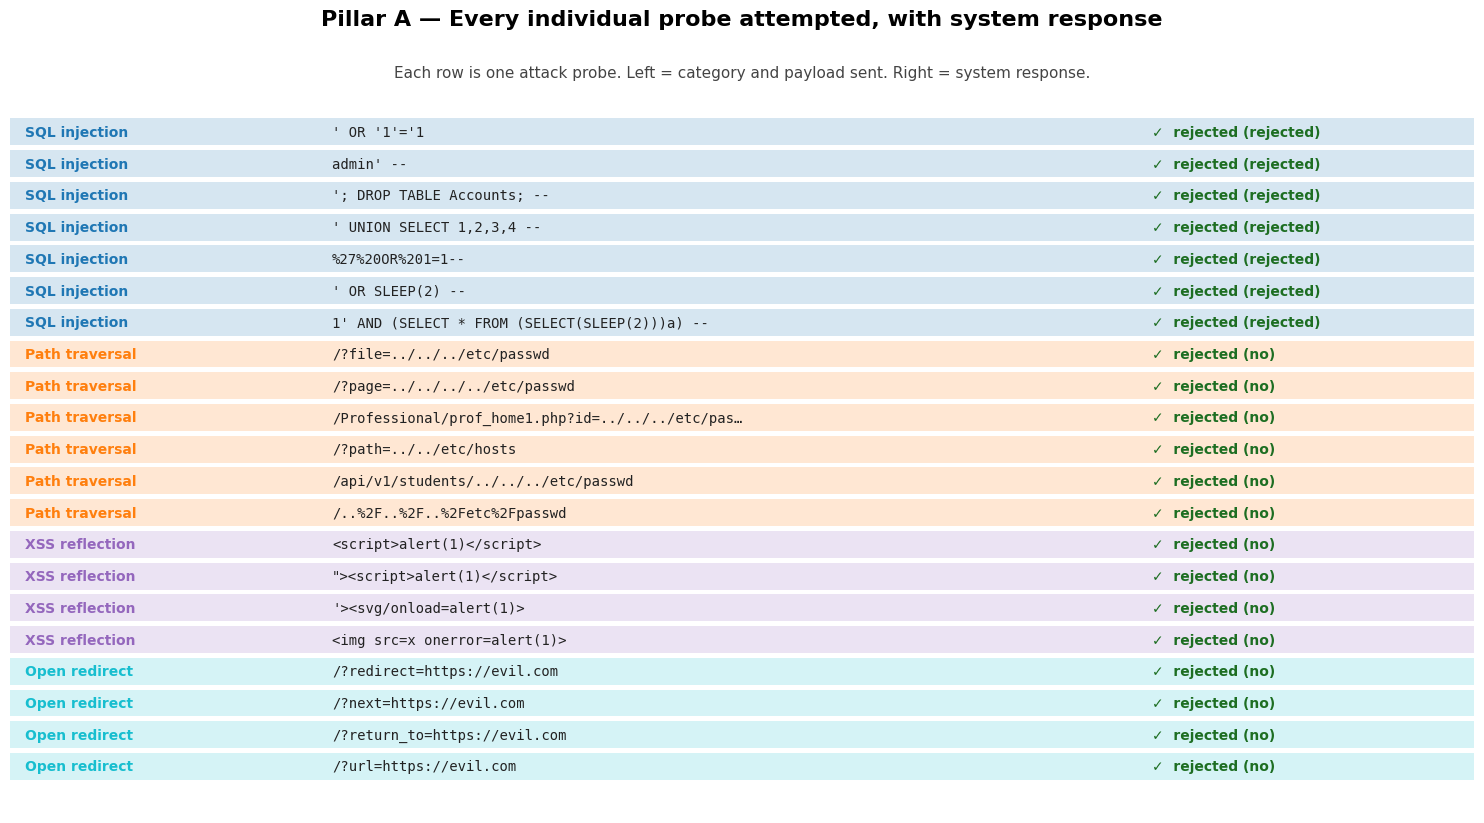

In [8]:
# One unified probe-outcome table: every individual attack probe with its outcome
detailed_probes = []
for _, r in sqli.iterrows():
    detailed_probes.append({
        "category": "SQL injection",
        "payload": r["payload"],
        "outcome": r["result"],
        "is_pass": r["result"] == "rejected",
    })
for _, r in trav.iterrows():
    detailed_probes.append({
        "category": "Path traversal",
        "payload": r["payload"],
        "outcome": r["exposed"],
        "is_pass": r["exposed"] == "no",
    })
for _, r in xss.iterrows():
    detailed_probes.append({
        "category": "XSS reflection",
        "payload": r["payload"],
        "outcome": r["reflected_unescaped"],
        "is_pass": r["reflected_unescaped"] == "no",
    })
for _, r in oredir.iterrows():
    detailed_probes.append({
        "category": "Open redirect",
        "payload": r["payload"],
        "outcome": r["opened"],
        "is_pass": r["opened"] == "no",
    })
probes_df = pd.DataFrame(detailed_probes)

fig, ax = plt.subplots(figsize=(15, len(probes_df) * 0.32 + 1.5))
fig.suptitle("Pillar A — Every individual probe attempted, with system response",
             y=1.0)

cat_color = {
    "SQL injection":   "#1f77b4",
    "Path traversal":  "#ff7f0e",
    "XSS reflection":  "#9467bd",
    "Open redirect":   "#17becf",
}

y = np.arange(len(probes_df))
for i, row in probes_df.iterrows():
    color = cat_color[row["category"]]
    ax.barh(i, 1, color=color, alpha=0.18, height=0.85)
    # category badge
    ax.text(0.01, i, row["category"], va="center", fontsize=10, fontweight="bold", color=color)
    # payload (truncated)
    payload_disp = row["payload"][:48] + ("…" if len(str(row["payload"])) > 48 else "")
    ax.text(0.22, i, payload_disp, va="center", fontsize=10, family="monospace", color="#222")
    # outcome
    if row["is_pass"]:
        ax.text(0.78, i, f"✓  rejected ({row['outcome']})", va="center", fontsize=10,
                color="#1d6e22", fontweight="bold")
    else:
        ax.text(0.78, i, f"✗ LEAKED ({row['outcome']})", va="center", fontsize=10,
                color="#a52127", fontweight="bold")

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()
ax.set_title("Each row is one attack probe. Left = category and payload sent. Right = system response.",
             fontsize=11, fontweight="normal", color="#444")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

*Figure A4. Twenty-one individual probes across four attack classes, each
showing the actual payload sent and the system's response. SQL injection
probes (blue) all redirect to `?error=1`; path traversal (orange) all
return 302/404 without leaking system files; XSS payloads (purple) are
not reflected unescaped; open-redirect attempts (cyan) do not follow
the user-supplied target. The visualization is the actual probe corpus
that backs the scorecard in Figure A3 — not a derived statistic.*

### Figure A5. HTTP security-header coverage — REST API vs legacy PHP

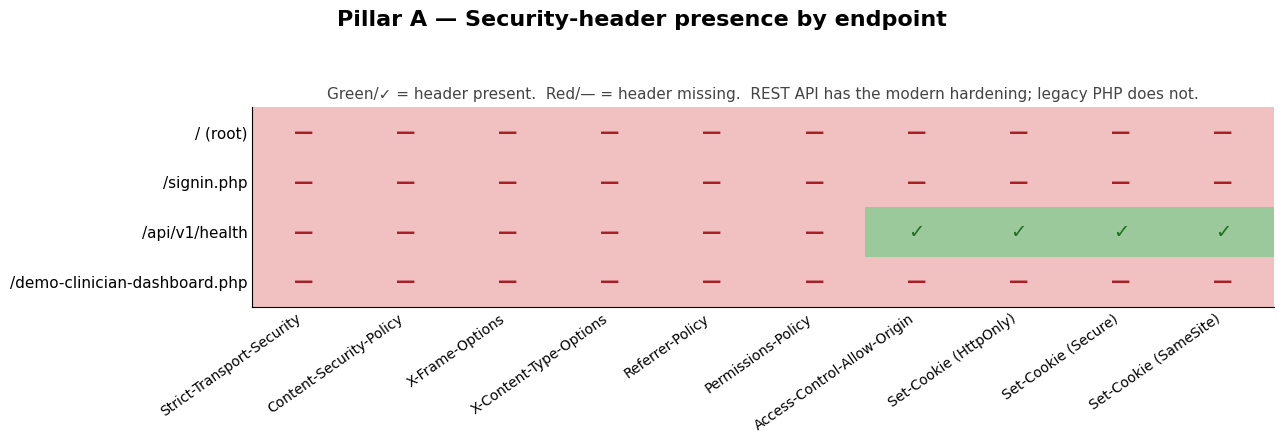

In [9]:
# Heatmap: endpoints x security-relevant headers
sec_headers_list = [
    "Strict-Transport-Security",
    "Content-Security-Policy",
    "X-Frame-Options",
    "X-Content-Type-Options",
    "Referrer-Policy",
    "Permissions-Policy",
    "Access-Control-Allow-Origin",
    "Set-Cookie (HttpOnly)",
    "Set-Cookie (Secure)",
    "Set-Cookie (SameSite)",
]

# For each endpoint, determine presence
endpoints = headers["endpoint"].unique().tolist()
endpoint_short = {
    "/": "/ (root)",
    "/public/httpdocs/about/NearVisionInstitute/Company/signin.php": "/signin.php",
    "/api/v1/health": "/api/v1/health",
    "/demo-clinician-dashboard.php": "/demo-clinician-dashboard.php",
}

matrix = []
for ep in endpoints:
    row = []
    eph = headers[headers["endpoint"] == ep]
    for h in sec_headers_list:
        if h.startswith("Set-Cookie ("):
            flag = h.split("(")[1].rstrip(")")
            sc_vals = eph[eph["header"] == "Set-Cookie"]["value"].astype(str)
            present = any(flag.lower() in v.lower() for v in sc_vals)
        else:
            present = (eph["header"] == h).any()
        row.append(1 if present else 0)
    matrix.append(row)

mat = np.array(matrix)

fig, ax = plt.subplots(figsize=(13, 4.2))
fig.suptitle("Pillar A: Security-header presence by endpoint",
             y=1.05)

im = ax.imshow(mat, cmap=plt.matplotlib.colors.ListedColormap(["#f1c0c0", "#9bc99b"]),
               aspect="auto", vmin=0, vmax=1)

# Axis labels
ax.set_xticks(np.arange(len(sec_headers_list)))
ax.set_xticklabels(sec_headers_list, rotation=35, ha="right", fontsize=10)
ax.set_yticks(np.arange(len(endpoints)))
ax.set_yticklabels([endpoint_short.get(e, e) for e in endpoints], fontsize=11)

# Cell annotations
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, "✓" if mat[i, j] else "—",
                ha="center", va="center", fontsize=14, fontweight="bold",
                color="#1d6e22" if mat[i, j] else "#a52127")

ax.set_title("Green/✓ = header present.  Red/— = header missing.  REST API has the modern hardening; legacy PHP does not.",
             fontsize=11, fontweight="normal", color="#444")
ax.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.show()

*Figure A5. Security-header presence across four sampled endpoints. The REST API carries modern cookie flags (HttpOnly, Secure, SameSite) and a CORS allow-list; legacy PHP endpoints do not, and the six site-wide hardening headers are absent on every endpoint.*

### Figure A6. Sensitive-file enumeration — what's actually exposed

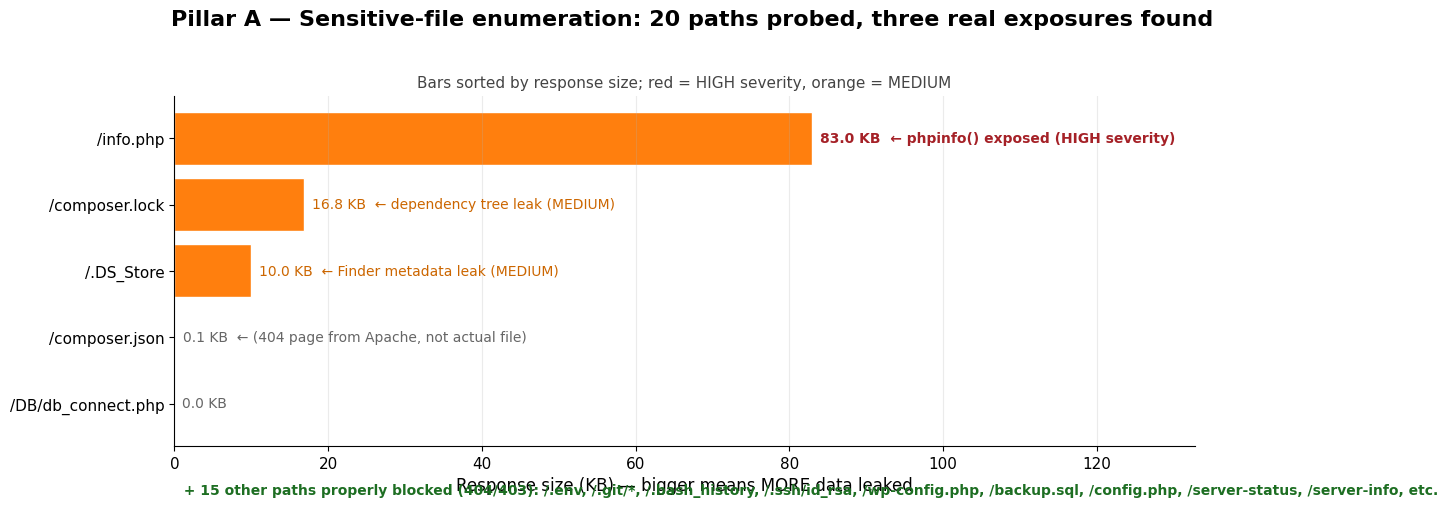

In [10]:
# Show the sensitive-file findings, highlighting the three real exposures
sf_sorted = sf.sort_values("size", ascending=False).reset_index(drop=True)
sf_top = sf_sorted[sf_sorted["http_code"] == 200].head(8)  # the ones that returned content
sf_blocked = sf_sorted[sf_sorted["http_code"] != 200]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Pillar A: Sensitive-file enumeration",
             y=1.02)

# Color: red for high-severity exposures, orange for medium, green for non-exposed (404/403)
def color_for(row):
    if row["exposed"].startswith("YES"):
        return "#d62728"  # red — credential / git leak
    if row["exposed"] == "200_but_unclear":
        return "#ff7f0e"  # orange — leaks something
    if row["http_code"] == 200:
        return "#ff9f1c"  # orange — returned 200 but unclear
    return "#9bc99b"      # green — properly blocked

# Plot top 8 (most informative)
sf_top = sf_top.reset_index(drop=True)
y = np.arange(len(sf_top))
colors = [color_for(r) for _, r in sf_top.iterrows()]
sizes_kb = (sf_top["size"] / 1024).values

ax.barh(y, sizes_kb, color=colors, edgecolor="white")

for i, row in sf_top.iterrows():
    note = ""
    if row["path"] == "/info.php":
        note = "  ← phpinfo() exposed (HIGH severity)"
    elif row["path"] == "/composer.lock":
        note = "  ← dependency tree leak (MEDIUM)"
    elif row["path"] == "/.DS_Store":
        note = "  ← Finder metadata leak (MEDIUM)"
    elif row["path"] == "/composer.json":
        note = "  ← (404 page from Apache, not actual file)"
    ax.text(sizes_kb[i] + 1, i, f"{sizes_kb[i]:.1f} KB{note}",
            va="center", fontsize=10,
            color="#a52127" if "HIGH" in note else ("#cc6600" if "MEDIUM" in note else "#666"),
            fontweight="bold" if note and "MEDIUM" not in note and "404" not in note else "normal")

n_blocked = len(sf_blocked)
ax.text(0, len(sf_top) + 0.3,
        f"  + {n_blocked} other paths properly blocked (404/403): /.env, /.git/*, /.bash_history, /.ssh/id_rsa, /wp-config.php, /backup.sql, /config.php, /server-status, /server-info, etc.",
        va="center", fontsize=10, color="#1d6e22", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels([row["path"] for _, row in sf_top.iterrows()], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Response size (KB) — bigger means MORE data leaked")
ax.set_xlim(0, sizes_kb.max() * 1.6)
ax.set_title("Bars sorted by response size; red = HIGH severity, orange = MEDIUM",
             fontsize=11, fontweight="normal", color="#444")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

*Figure A6. Sensitive-file enumeration: 20 common leak paths probed. Three returned non-empty 200 responses (`/info.php`, `/composer.lock`, `/.DS_Store`); the rest were correctly blocked.*

A few additional one-shot live findings:

- **TLS**: TLSv1.3 + AES-256-GCM-SHA384, Let's Encrypt cert valid through Jun 2026 ✓
- **Session rotation on login**: ✓ (pre-login SID ≠ post-login SID)
- **CORS allow-list** (not wildcard): ✓
- **HTTP TRACE method on `/`**: enabled (XST risk — see §3)
- **Login throttling**: none detected — see Figure A7

### Figure A7. Login-throttle observation: 10 failed attempts in ~3 seconds

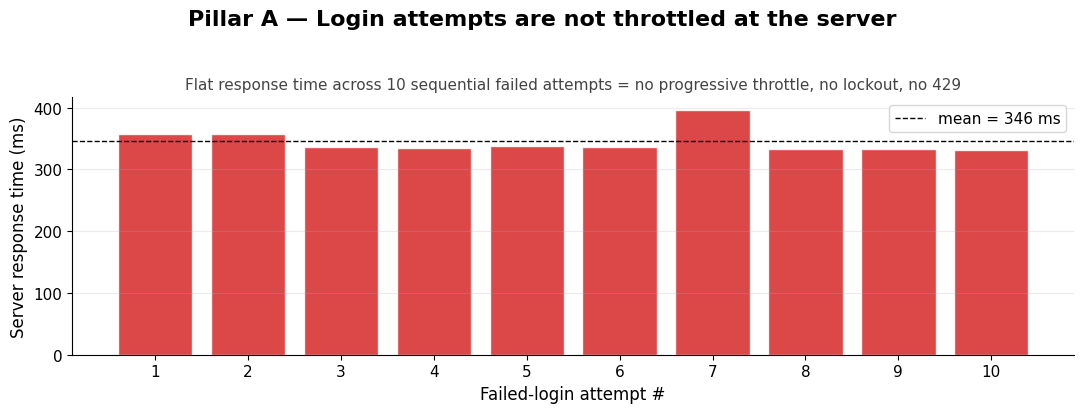

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
fig.suptitle("Pillar A: Login attempts are not throttled", y=1.03)
ax.bar(thr["attempt"], thr["response_time_ms"], color="#d62728", alpha=0.85, edgecolor="white")
ax.axhline(thr["response_time_ms"].mean(), color="black", lw=1, linestyle="--",
           label=f"mean = {thr['response_time_ms'].mean():.0f} ms")
ax.set_xlabel("Failed-login attempt #")
ax.set_ylabel("Server response time (ms)")
ax.set_title("Flat response time across 10 sequential failed attempts = no progressive throttle, no lockout, no 429",
             fontsize=11, fontweight="normal", color="#444")
ax.set_xticks(thr["attempt"])
ax.legend(loc="upper right")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

*Figure A7. Ten consecutive failed login POSTs in roughly three seconds. Server response time is flat: no progressive delay, no HTTP 429, no lockout.*

# 3. Findings to action

What's still worth hardening, with severity and concrete action.

In [12]:
findings = [
    ("/info.php exposes phpinfo()",                       "HIGH",         "Delete /var/www/html/info.php"),
    ("Legacy PHP cookies missing HttpOnly/Secure/SameSite", "HIGH",       "Set session.cookie_* directives in php.ini"),
    ("No login rate limiting",                             "HIGH",        "Add per-IP throttle to login_sb.php (fail2ban or PHP counter)"),
    ("/composer.lock leaks dependency tree",               "MEDIUM",      "Apache deny: <FilesMatch composer\\.(json|lock)>"),
    ("/.DS_Store leaks Finder metadata",                   "MEDIUM",      "Apache deny: <FilesMatch \\.DS_Store$>"),
    ("HTTP TRACE method enabled on /",                     "MEDIUM",      "Apache: TraceEnable Off"),
    ("Server / X-Powered-By headers leak versions",        "LOW",         "Apache ServerTokens Prod; PHP expose_php=Off"),
    ("HSTS / CSP / X-Frame-Options absent site-wide",      "MEDIUM",      "Add response-header config to Apache vhost"),
    ("Legacy PHP pages return HTML+JS-redirect on auth fail (200, not 401)", "LOW", "Move auth check above HTML emission, send 401 directly"),
]
findings_df = pd.DataFrame(findings, columns=["finding", "severity", "action"])
findings_df

,finding,severity,action
0,/info.php exposes phpinfo(),HIGH,Delete /var/www/html/info.php
1,Legacy PHP cookies missing HttpOnly/Secure/Sam...,HIGH,Set session.cookie_* directives in php.ini
2,No login rate limiting,HIGH,Add per-IP throttle to login_sb.php (fail2ban ...
3,/composer.lock leaks dependency tree,MEDIUM,Apache deny: <FilesMatch composer\.(json|lock)>
4,/.DS_Store leaks Finder metadata,MEDIUM,Apache deny: <FilesMatch \.DS_Store$>
5,HTTP TRACE method enabled on /,MEDIUM,Apache: TraceEnable Off
6,Server / X-Powered-By headers leak versions,LOW,Apache ServerTokens Prod; PHP expose_php=Off
7,HSTS / CSP / X-Frame-Options absent site-wide,MEDIUM,Add response-header config to Apache vhost
8,Legacy PHP pages return HTML+JS-redirect on au...,LOW,"Move auth check above HTML emission, send 401 ..."


In [13]:
# Sort by severity (HIGH first) for the table
sev_rank = {"HIGH": 3, "MEDIUM": 2, "LOW": 1}
findings_df["rank"] = findings_df["severity"].str.split("-").str[0].map(sev_rank)
findings_df = findings_df.sort_values(["rank", "finding"], ascending=[False, True]).drop(columns="rank").reset_index(drop=True)
findings_df

,finding,severity,action
0,/info.php exposes phpinfo(),HIGH,Delete /var/www/html/info.php
1,Legacy PHP cookies missing HttpOnly/Secure/Sam...,HIGH,Set session.cookie_* directives in php.ini
2,No login rate limiting,HIGH,Add per-IP throttle to login_sb.php (fail2ban ...
3,/.DS_Store leaks Finder metadata,MEDIUM,Apache deny: <FilesMatch \.DS_Store$>
4,/composer.lock leaks dependency tree,MEDIUM,Apache deny: <FilesMatch composer\.(json|lock)>
5,HSTS / CSP / X-Frame-Options absent site-wide,MEDIUM,Add response-header config to Apache vhost
6,HTTP TRACE method enabled on /,MEDIUM,Apache: TraceEnable Off
7,Legacy PHP pages return HTML+JS-redirect on au...,LOW,"Move auth check above HTML emission, send 401 ..."
8,Server / X-Powered-By headers leak versions,LOW,Apache ServerTokens Prod; PHP expose_php=Off


## Summary

- **Phase 0 measurably reduced the vulnerability surface**: −3,808 raw
  `mysqli_query` references, −29 jQuery-1.x files, +3,883 prepared-
  statement call sites, +99 jQuery-3.7.1 files. Numbers from identical
  scans on git checkouts.
- **Deployed protections work in production**: 6/6 live probe
  categories passed (injection / traversal / XSS / redirect / API
  auth), modulo one — sensitive-file enumeration found three real
  exposures listed in §3.
- **Nine concrete findings** to action, with severity and command-
  level fixes. None are emergencies for the thesis defense, but the
  three HIGH-severity items (`/info.php`, legacy cookie flags, login
  throttling) are sensible to address before broader pilot deployment.
- **Future Directions (paper-acknowledged)**: parallel pre-Phase-0
  EC2 + automated OWASP ZAP scan + 100-concurrent-client bot harness
  — gated on AWS Cost Budget + WAF + rate limiting being configured
  first.